# U-Net Carvana -- Evaluation

Evaluates the trained U-Net checkpoint on the reconstructed val split.
Computes per-image IoU and Dice, prints a summary table, and saves:
- `evaluation_results.csv` -- per-image filename, IoU, Dice
- `evaluation_grid.png` -- 4-panel grid: input | ground-truth mask | prediction | error map

**Data sources required:**
- Carvana PNG dataset: `ipythonx/carvana-image-masking-png`
- Module dataset: `mendelowitzadi/unet-segmentation-modules`
- Training notebook output (for checkpoint): attach `train-unet-carvana` notebook output

Reference: Ronneberger, Fischer, Brox. "U-Net: Convolutional Networks for Biomedical Image Segmentation." MICCAI 2015.

## 1. Imports

In [1]:
import csv
import pathlib
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision.transforms import functional as TF

# Allow loading checkpoints that contain PosixPath/WindowsPath objects.
torch.serialization.add_safe_globals([pathlib.PosixPath, pathlib.WindowsPath])

import sys
sys.path.append("/kaggle/input/datasets/mendelowitzadi/unet-segmentation-modules")
from segmentation_loss import dice_loss, iou_score
from unet import UNet

print("Imports OK")

Imports OK


## 2. Config

In [2]:
CONFIG = {
    "img_dir":        Path("/kaggle/input/datasets/ipythonx/carvana-image-masking-png/train_images"),
    "mask_dir":       Path("/kaggle/input/datasets/ipythonx/carvana-image-masking-png/train_masks"),
    "checkpoint":     Path("/kaggle/input/notebooks/mendelowitzadi/train-unet-carvana/checkpoints/best_unet_carvana.pth"),
    "img_size":       512,
    "in_channels":    3,
    "num_classes":    1,
    "val_fraction":   0.1,
    "batch_size":     8,
    "threshold":      0.5,
    "n_grid_samples": 8,
    "seed":           42,
}

# ImageNet statistics -- must match train_unet_carvana.ipynb exactly.
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 3. Reconstruct val split

Replicates the exact split logic from `train_unet_carvana.ipynb`:
`torch.randperm(n, generator=rng)`, last `n_val` indices are validation.

In [3]:
def build_val_ids(img_dir: Path, val_fraction: float, seed: int) -> list[str]:
    all_ids = sorted(p.stem for p in img_dir.glob("*.jpg"))
    if not all_ids:
        raise FileNotFoundError(f"No .jpg images found in {img_dir}")
    n_total = len(all_ids)
    n_val = max(1, int(n_total * val_fraction))
    rng = torch.Generator().manual_seed(seed)
    indices = torch.randperm(n_total, generator=rng).tolist()
    val_indices = indices[n_total - n_val:]
    return [all_ids[i] for i in sorted(val_indices)]


val_ids = build_val_ids(CONFIG["img_dir"], CONFIG["val_fraction"], CONFIG["seed"])
print(f"Val images: {len(val_ids)}")
print(f"First 5 IDs: {val_ids[:5]}")

Val images: 508
First 5 IDs: ['00087a6bd4dc_11', '02159e548029_10', '0495dcf27283_02', '0495dcf27283_05', '0495dcf27283_15']


## 4. Data helpers

In [8]:
def load_image(img_dir: Path, stem: str, img_size: int) -> torch.Tensor:
    """Load, resize, and normalize an RGB image. Returns (3, H, W) float32."""
    img = Image.open(img_dir / f"{stem}.jpg").convert("RGB")
    img = TF.resize(img, (img_size, img_size), interpolation=TF.InterpolationMode.BILINEAR)
    t = TF.to_tensor(img)
    return TF.normalize(t, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


def load_mask(mask_dir: Path, stem: str, img_size: int) -> torch.Tensor:
    """Load, resize (nearest), and binarize a mask. Returns (1, H, W) float32."""
    mask = Image.open(mask_dir / f"{stem}.png").convert("L")
    mask = TF.resize(mask, (img_size, img_size), interpolation=TF.InterpolationMode.NEAREST)
    mask_t = torch.from_numpy(np.array(mask)).unsqueeze(0).float()
    if mask_t.max() > 1.0:
        mask_t = mask_t / 255.0
    return (mask_t > 0.5).float()


def denormalize(img_tensor: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalization for display. Returns (H, W, 3) float32 in [0, 1]."""
    img = img_tensor.cpu() * _STD + _MEAN
    return img.permute(1, 2, 0).clamp(0.0, 1.0).numpy()


print("Data helpers defined")

Data helpers defined


## 5. Load checkpoint

In [9]:
checkpoint = torch.load(CONFIG["checkpoint"], map_location=DEVICE, weights_only=True)
model = UNet(in_channels=CONFIG["in_channels"], num_classes=CONFIG["num_classes"]).to(DEVICE)
model.load_state_dict(checkpoint["model"])
model.eval()

print(
    f"Checkpoint loaded:\n"
    f"  epoch    = {checkpoint['epoch']}\n"
    f"  val_loss = {checkpoint['val_loss']:.4f}\n"
    f"  val_dice = {checkpoint['val_dice']:.4f}"
)

Checkpoint loaded:
  epoch    = 20
  val_loss = 0.0044
  val_dice = 0.9955


## 6. Per-image evaluation

In [10]:
@torch.no_grad()
def run_evaluation(model, val_ids, config, device):
    model.eval()
    results = []
    img_dir  = config["img_dir"]
    mask_dir = config["mask_dir"]
    img_size = config["img_size"]
    bs       = config["batch_size"]

    for start in range(0, len(val_ids), bs):
        batch_ids = val_ids[start: start + bs]

        imgs  = torch.stack([load_image(img_dir, sid, img_size) for sid in batch_ids]).to(device)
        masks = torch.stack([load_mask(mask_dir, sid, img_size) for sid in batch_ids]).to(device)

        probs = torch.sigmoid(model(imgs).float())

        for i, sid in enumerate(batch_ids):
            p = probs[i].unsqueeze(0)   # (1, 1, H, W)
            m = masks[i].unsqueeze(0)   # (1, 1, H, W)
            iou  = iou_score(p, m, threshold=config["threshold"]).item()
            dice = (1.0 - dice_loss(p, m)).item()
            results.append({"filename": sid, "iou": iou, "dice": dice})

        if (start // bs + 1) % 10 == 0:
            print(f"  {min(start + bs, len(val_ids))}/{len(val_ids)} evaluated")

    return results


print("Running per-image evaluation...")
results = run_evaluation(model, val_ids, CONFIG, DEVICE)

ious  = [r["iou"]  for r in results]
dices = [r["dice"] for r in results]

print(f"\n{'Metric':<10} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 46)
print(f"{'IoU':<10} {np.mean(ious):>8.4f} {np.std(ious):>8.4f} {np.min(ious):>8.4f} {np.max(ious):>8.4f}")
print(f"{'Dice':<10} {np.mean(dices):>8.4f} {np.std(dices):>8.4f} {np.min(dices):>8.4f} {np.max(dices):>8.4f}")
print(f"\nImages evaluated: {len(results)}")

Running per-image evaluation...
  80/508 evaluated
  160/508 evaluated
  240/508 evaluated
  320/508 evaluated
  400/508 evaluated
  480/508 evaluated

Metric         Mean      Std      Min      Max
----------------------------------------------
IoU          0.9932   0.0020   0.9764   0.9967
Dice         0.9955   0.0011   0.9868   0.9973

Images evaluated: 508


## 7. Save results CSV

In [11]:
csv_path = Path("/kaggle/working/evaluation_results.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["filename", "iou", "dice"])
    writer.writeheader()
    writer.writerows(results)
print(f"Saved {csv_path}")

Saved /kaggle/working/evaluation_results.csv


## 8. Visualization grid

4-panel grid: input | ground-truth mask | prediction | error map

Error map: red = false positive (predicted car, actually background), blue = false negative (missed car pixel).

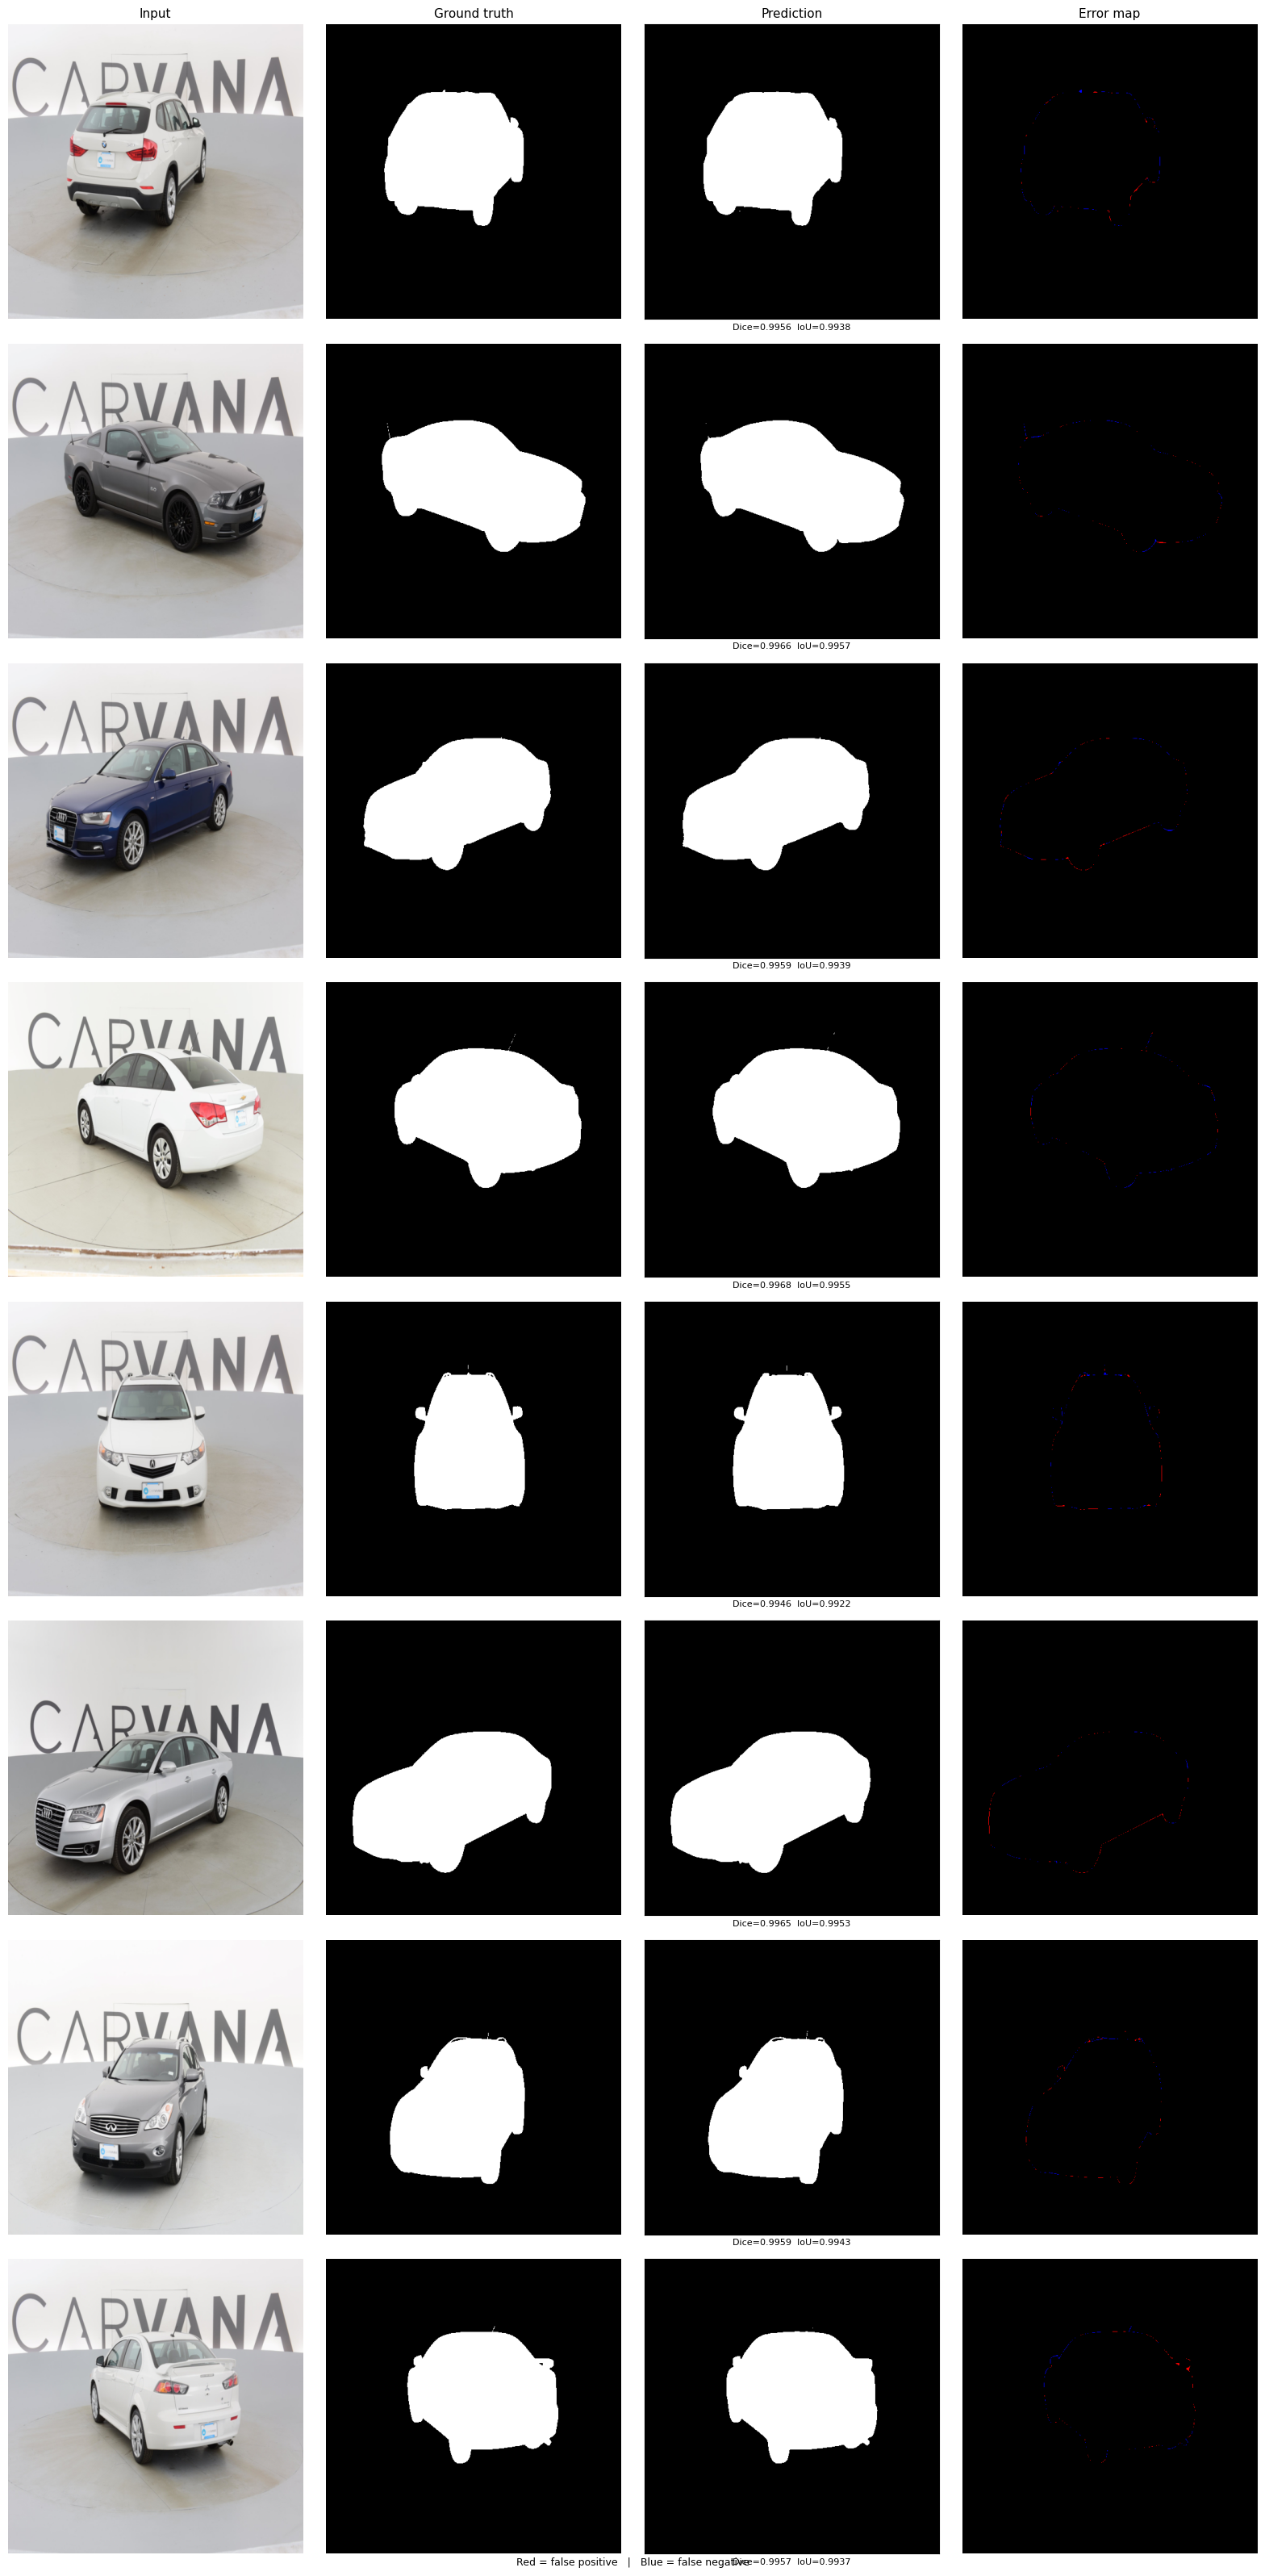

Saved /kaggle/working/evaluation_grid.png


In [12]:
random.seed(CONFIG["seed"])
sample_ids = random.sample(val_ids, min(CONFIG["n_grid_samples"], len(val_ids)))

img_dir  = CONFIG["img_dir"]
mask_dir = CONFIG["mask_dir"]
img_size = CONFIG["img_size"]
n        = len(sample_ids)

imgs  = torch.stack([load_image(img_dir, sid, img_size) for sid in sample_ids]).to(DEVICE)
masks = torch.stack([load_mask(mask_dir, sid, img_size) for sid in sample_ids]).to(DEVICE)

with torch.no_grad():
    probs = torch.sigmoid(model(imgs).float())
    preds = (probs > CONFIG["threshold"]).float()

fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
col_titles = ["Input", "Ground truth", "Prediction", "Error map"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for i, sid in enumerate(sample_ids):
    img_np  = denormalize(imgs[i].cpu())
    gt_np   = masks[i].cpu().squeeze().numpy()
    pred_np = preds[i].cpu().squeeze().numpy()

    # Red = false positive, blue = false negative.
    error_rgb = np.zeros((*gt_np.shape, 3), dtype=np.float32)
    error_rgb[..., 0] = (pred_np == 1) & (gt_np == 0)   # FP
    error_rgb[..., 2] = (pred_np == 0) & (gt_np == 1)   # FN

    axes[i, 0].imshow(img_np)
    axes[i, 1].imshow(gt_np,   cmap="gray", vmin=0, vmax=1)
    axes[i, 2].imshow(pred_np, cmap="gray", vmin=0, vmax=1)
    axes[i, 3].imshow(error_rgb)

    # Per-image Dice annotation on the prediction panel.
    r = next(x for x in results if x["filename"] == sid)
    axes[i, 2].set_xlabel(f"Dice={r['dice']:.4f}  IoU={r['iou']:.4f}", fontsize=8)

    for ax in axes[i]:
        ax.axis("off")
    axes[i, 2].axis("on")
    axes[i, 2].set_xticks([])
    axes[i, 2].set_yticks([])

    axes[i, 0].set_ylabel(sid, fontsize=7, rotation=0, labelpad=80, va="center")

fig.text(0.5, 0.005, "Red = false positive   |   Blue = false negative", ha="center", fontsize=9)
plt.tight_layout()
grid_path = Path("/kaggle/working/evaluation_grid.png")
plt.savefig(grid_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved {grid_path}")

## 9. Histogram of per-image Dice scores

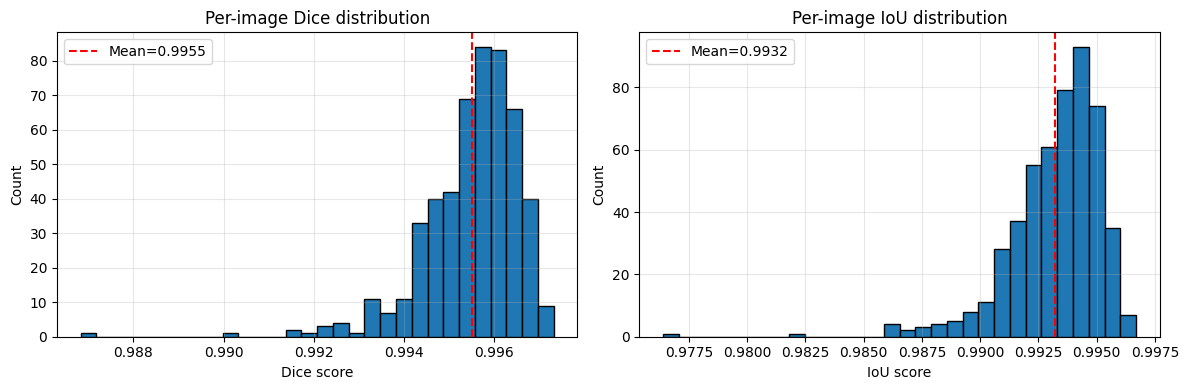

Saved /kaggle/working/metrics_histogram.png


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(dices, bins=30, edgecolor="black")
ax1.set_xlabel("Dice score")
ax1.set_ylabel("Count")
ax1.set_title("Per-image Dice distribution")
ax1.axvline(np.mean(dices), color="red", linestyle="--", label=f"Mean={np.mean(dices):.4f}")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(ious, bins=30, edgecolor="black")
ax2.set_xlabel("IoU score")
ax2.set_ylabel("Count")
ax2.set_title("Per-image IoU distribution")
ax2.axvline(np.mean(ious), color="red", linestyle="--", label=f"Mean={np.mean(ious):.4f}")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
hist_path = Path("/kaggle/working/metrics_histogram.png")
plt.savefig(hist_path, dpi=120)
plt.show()
print(f"Saved {hist_path}")